## 03 Procesamiento de Data

1. Revisión de datos (primeros 5 y ultimos 5)
2. Eliminamos las columnas irrelevantes para el análisis.
3. Ingeniería de atributos (Pandemia)
4. Eliminación de meses de "Pandemia"
5. Separacion de variables categoricas y numericas
6. Variables numéricas
   1. Convertimos a log1p las variables con asimetría positiva.
   2. Identificación de Outliers (IQR). 
   3. Imputación de Nulos mediante Random forest regresor
   4. Medimos la correlación de varibales numéricas
   5. Devolvemos las variables a su valor original.
7. Juntamos las variables numéricas imputadas con las vairables Categóricas
8. Guardado de datos preprocesados.

In [6]:
import pandas as pd

# Configuraciones del notebbok
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

data_base = pd.read_csv('../Data/Row/Flujo vehicular registrado en peajes_2014-2025_II.csv', encoding='latin-1')
data_pbi = pd.read_excel('../Data/Row/PBI_Mensual_201401_202508.xlsx', sheet_name='Mensuales')
data_feriados = pd.read_csv('../Data/Row/Feriados_No_Laborables_Fines_de_semana.csv')

# Tratamos el dataset PBI
data_pbi['Mes'].unique()

dic_mes = {'Ene':1, 'Feb':2, 'Mar':3, 'Abr':4, 'May':5, 'Jun':6, 'Jul':7, 'Ago':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dic':12}
dic_anio = {'14':'2014', '15':'2015', '16':'2016', '17':'2017', '18':'2018', '19':'2019', '20':'2020', '21':'2021', '22':'2022', '23':'2023', '24':'2024', '25':'2025'}
data_pbi['Mes_str'] = data_pbi['Mes'].apply(lambda x: dic_mes[x[:3]])
data_pbi['Anio_str'] = data_pbi['Mes'].apply(lambda x: dic_anio[x[3:]])

# Creamos las llaves
data_base['llave'] = data_base['ANIO'].astype(str) + data_base['MES'].astype(str)
data_pbi['llave'] = data_pbi['Anio_str'].astype(str) + data_pbi['Mes_str'].astype(str)
data_feriados['llave'] = data_feriados['Anio'].astype(str) + data_feriados['Mes'].astype(str)

# juntamos la información
data_merge_01 = data_base.merge(data_pbi, on='llave', how='left')
data_total = data_merge_01.merge(data_feriados, on='llave', how='left')

# Eliminamos columnas no significativas o innecesarias del merge
data_total_f = data_total.drop(columns=['Mes_str', 'Anio_str', 'Mes_y', 'ID', 'Mes_x', 'Anio', 'NOMBRE_PEAJE'])

In [8]:
data_total_f.columns

Index(['ADMINIST', 'CODIGO_PEAJE', 'DEPARTAMENTO', 'VEH_LIGEROS_TAR_DIF',
       'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS_TAR_DIF', 'VEH_PESADOS__2E',
       'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E',
       'VEH_PESADOS_7E', 'VEH_LIGEROS_TOTAL', 'VEH_LIGEROS_IMD',
       'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 'VEH_TOTAL', 'VEH_IMD', 'ANIO',
       'MES', 'PERIODO', 'llave', 'PBI', 'Feriados',
       'No_Laborables_Fuera_de_Feriado', 'Fines_de_Semana'],
      dtype='object')

In [14]:
# Eliminamos las oclumnas que no nos sirven
df_prep = data_total_f.copy()

df_prep.head(5)

,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO,llave,PBI,Feriados,No_Laborables_Fuera_de_Feriado,Fines_de_Semana
0,Concesionado,22PE5NACS1,San Martín,2099,8070.0,0,2586.0,2374.0,720.0,315.0,3512.0,8.0,10169,328.0,9515,306.9,19684,635.0,2014,1,201401,20141,136.331425,1,1,8
1,Concesionado,04PE1SCAM1,Arequipa,0,24644.0,0,6502.0,4622.0,1654.0,3028.0,8711.0,213.0,24644,795.0,24730,797.7,49374,1592.7,2014,1,201401,20141,136.331425,1,1,8
2,Concesionado,21PE3SCRO1,Puno,33643,82139.0,5797,17981.0,5307.0,1150.0,1737.0,5342.0,12.0,115782,3734.9,37326,1204.1,153108,4939.0,2014,1,201401,20141,136.331425,1,1,8
3,Concesionado,12PE3NCRA1,Junín,10,46944.0,0,16981.0,18585.0,4463.0,3058.0,19400.0,135.0,46954,1514.6,62622,2020.1,109576,3534.7,2014,1,201401,20141,136.331425,1,1,8
4,Concesionado,08PE3SCSC1,Cusco,0,23831.0,0,4709.0,3941.0,447.0,769.0,3945.0,95.0,23831,768.7,13906,448.6,37737,1217.3,2014,1,201401,20141,136.331425,1,1,8


In [15]:
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ADMINIST                        10781 non-null  object 
 1   CODIGO_PEAJE                    10781 non-null  object 
 2   DEPARTAMENTO                    10781 non-null  object 
 3   VEH_LIGEROS_TAR_DIF             10781 non-null  int64  
 4   VEH_LIGEROS_AUTOMOVILES         10768 non-null  float64
 5   VEH_PESADOS_TAR_DIF             10781 non-null  int64  
 6   VEH_PESADOS__2E                 10773 non-null  float64
 7   VEH_PESADOS_3E                  10773 non-null  float64
 8   VEH_PESADOS_4E                  10773 non-null  float64
 9   VEH_PESADOS_5E                  10773 non-null  float64
 10  VEH_PESADOS_6E                  10773 non-null  float64
 11  VEH_PESADOS_7E                  10773 non-null  float64
 12  VEH_LIGEROS_TOTAL               

In [17]:
# Feature Enginnering
df_prep['Pandemia'] = df_prep['PERIODO'].apply(lambda x: 1 if str(x).startswith('2020') else 0 )

df_prep.head(5)

,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO,llave,PBI,Feriados,No_Laborables_Fuera_de_Feriado,Fines_de_Semana,Pandemia
0,Concesionado,22PE5NACS1,San Martín,2099,8070.0,0,2586.0,2374.0,720.0,315.0,3512.0,8.0,10169,328.0,9515,306.9,19684,635.0,2014,1,201401,20141,136.331425,1,1,8,0
1,Concesionado,04PE1SCAM1,Arequipa,0,24644.0,0,6502.0,4622.0,1654.0,3028.0,8711.0,213.0,24644,795.0,24730,797.7,49374,1592.7,2014,1,201401,20141,136.331425,1,1,8,0
2,Concesionado,21PE3SCRO1,Puno,33643,82139.0,5797,17981.0,5307.0,1150.0,1737.0,5342.0,12.0,115782,3734.9,37326,1204.1,153108,4939.0,2014,1,201401,20141,136.331425,1,1,8,0
3,Concesionado,12PE3NCRA1,Junín,10,46944.0,0,16981.0,18585.0,4463.0,3058.0,19400.0,135.0,46954,1514.6,62622,2020.1,109576,3534.7,2014,1,201401,20141,136.331425,1,1,8,0
4,Concesionado,08PE3SCSC1,Cusco,0,23831.0,0,4709.0,3941.0,447.0,769.0,3945.0,95.0,23831,768.7,13906,448.6,37737,1217.3,2014,1,201401,20141,136.331425,1,1,8,0


In [18]:
# Eliminamos del analisis el tiempo de periodo de la pandemia - (No considerar todo el año - Evaluar)
df_filter = df_prep[df_prep['Pandemia'] != 1]

In [19]:
# Separacion de variables por numericas y categoricas

df_prep_num = df_filter.select_dtypes(include=['int64', 'float64','number'])
df_prep_cat = df_filter.select_dtypes(include=['object', 'category'])

### Trabajamos las variables numéricas

In [21]:
df_prep_num.head()

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO,PBI,Feriados,No_Laborables_Fuera_de_Feriado,Fines_de_Semana,Pandemia
0,2099,8070.0,0,2586.0,2374.0,720.0,315.0,3512.0,8.0,10169,328.0,9515,306.9,19684,635.0,2014,1,201401,136.331425,1,1,8,0
1,0,24644.0,0,6502.0,4622.0,1654.0,3028.0,8711.0,213.0,24644,795.0,24730,797.7,49374,1592.7,2014,1,201401,136.331425,1,1,8,0
2,33643,82139.0,5797,17981.0,5307.0,1150.0,1737.0,5342.0,12.0,115782,3734.9,37326,1204.1,153108,4939.0,2014,1,201401,136.331425,1,1,8,0
3,10,46944.0,0,16981.0,18585.0,4463.0,3058.0,19400.0,135.0,46954,1514.6,62622,2020.1,109576,3534.7,2014,1,201401,136.331425,1,1,8,0
4,0,23831.0,0,4709.0,3941.0,447.0,769.0,3945.0,95.0,23831,768.7,13906,448.6,37737,1217.3,2014,1,201401,136.331425,1,1,8,0


C:\Users\lenovo\AppData\Local\Temp\ipykernel_11860\887561714.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_prep_num[atribute], fill=True)


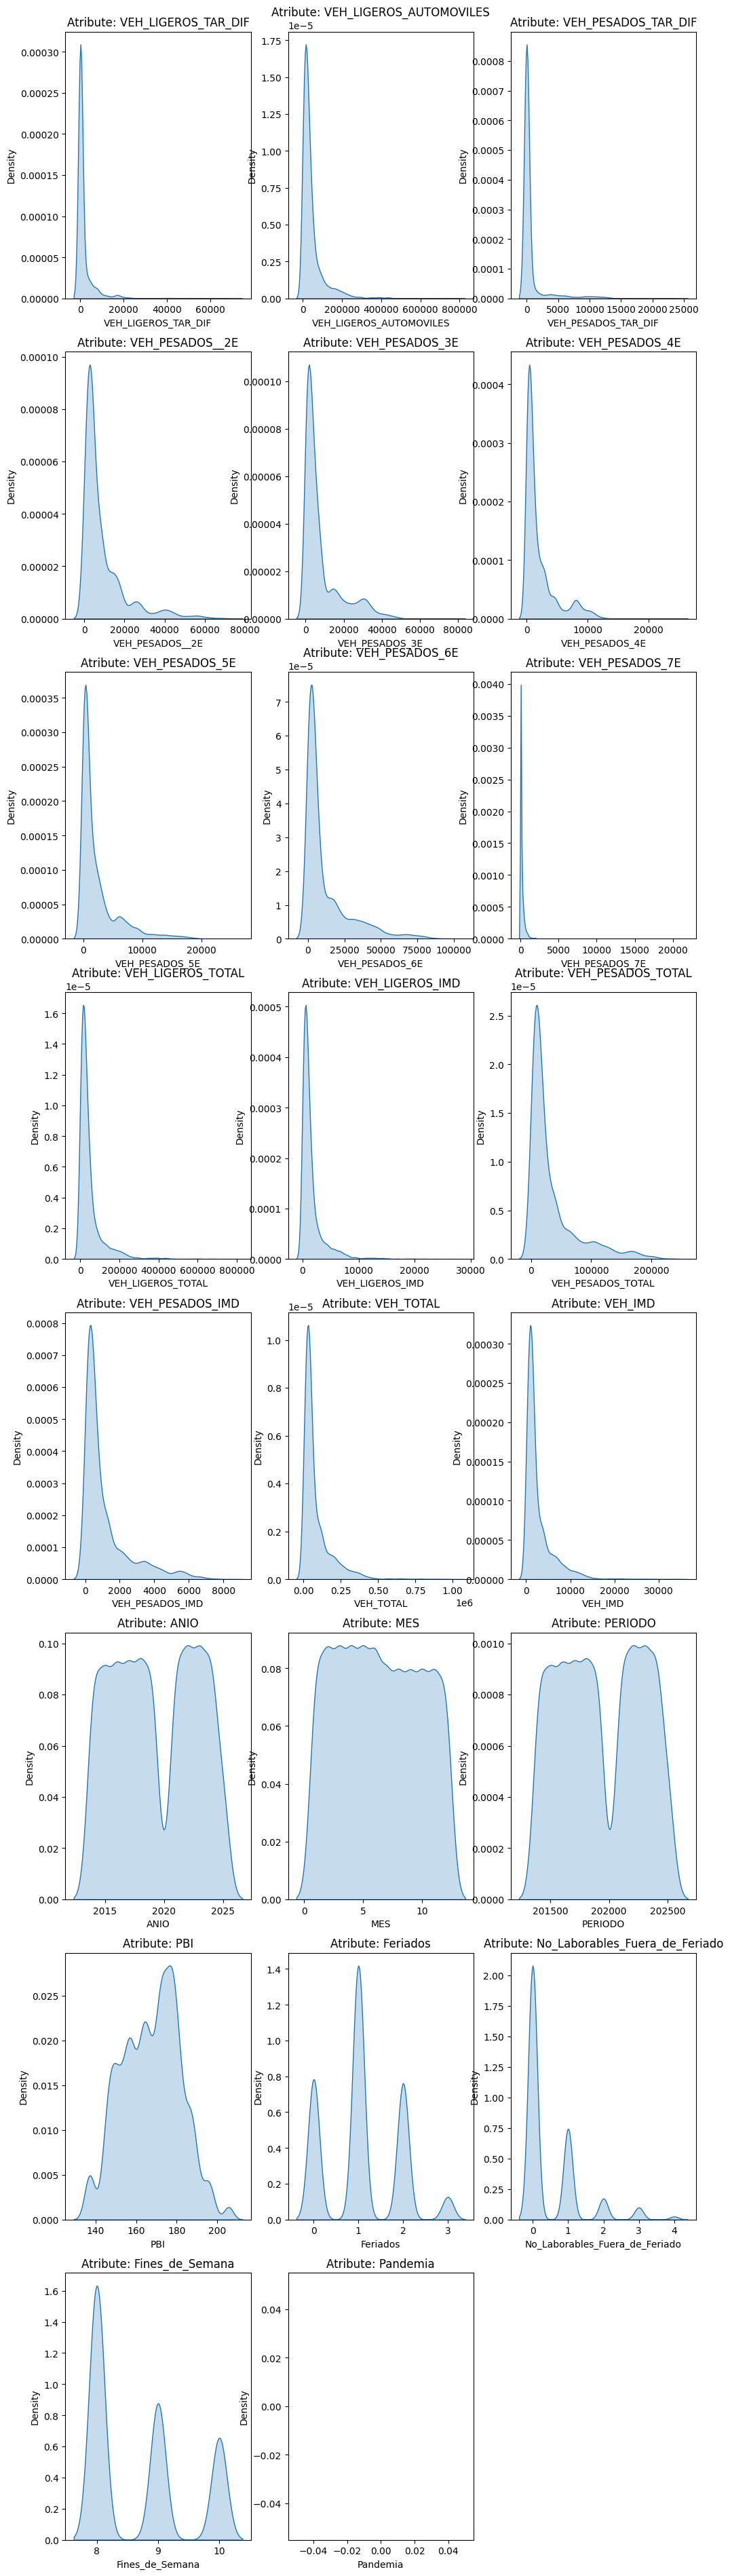

In [22]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 3

n_vars = len(df_prep_num.columns)
n_rows = math.ceil(n_vars / n_cols)

plt.figure(figsize=(12, n_rows*6))

for i, atribute in enumerate(df_prep_num.columns):
    plt.subplot(n_rows, n_cols, i+1)
    sns.kdeplot(df_prep_num[atribute], fill=True)

    plt.title(f'Atribute: {atribute}')

In [23]:
df_prep_num.columns

Index(['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS_TAR_DIF',
       'VEH_PESADOS__2E', 'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E',
       'VEH_PESADOS_6E', 'VEH_PESADOS_7E', 'VEH_LIGEROS_TOTAL',
       'VEH_LIGEROS_IMD', 'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 'VEH_TOTAL',
       'VEH_IMD', 'ANIO', 'MES', 'PERIODO', 'PBI', 'Feriados',
       'No_Laborables_Fuera_de_Feriado', 'Fines_de_Semana', 'Pandemia'],
      dtype='object')

In [24]:
import numpy as np

columnas_a_normalizar = ['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS_TAR_DIF',
       'VEH_PESADOS__2E', 'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E',
       'VEH_PESADOS_6E', 'VEH_PESADOS_7E']

df_prep_num_log = df_prep_num.copy()

for col in columnas_a_normalizar:
    df_prep_num_log[col] = df_prep_num[col].apply(np.log1p)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_11860\4200661542.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_prep_num_log[atribute], fill=True)


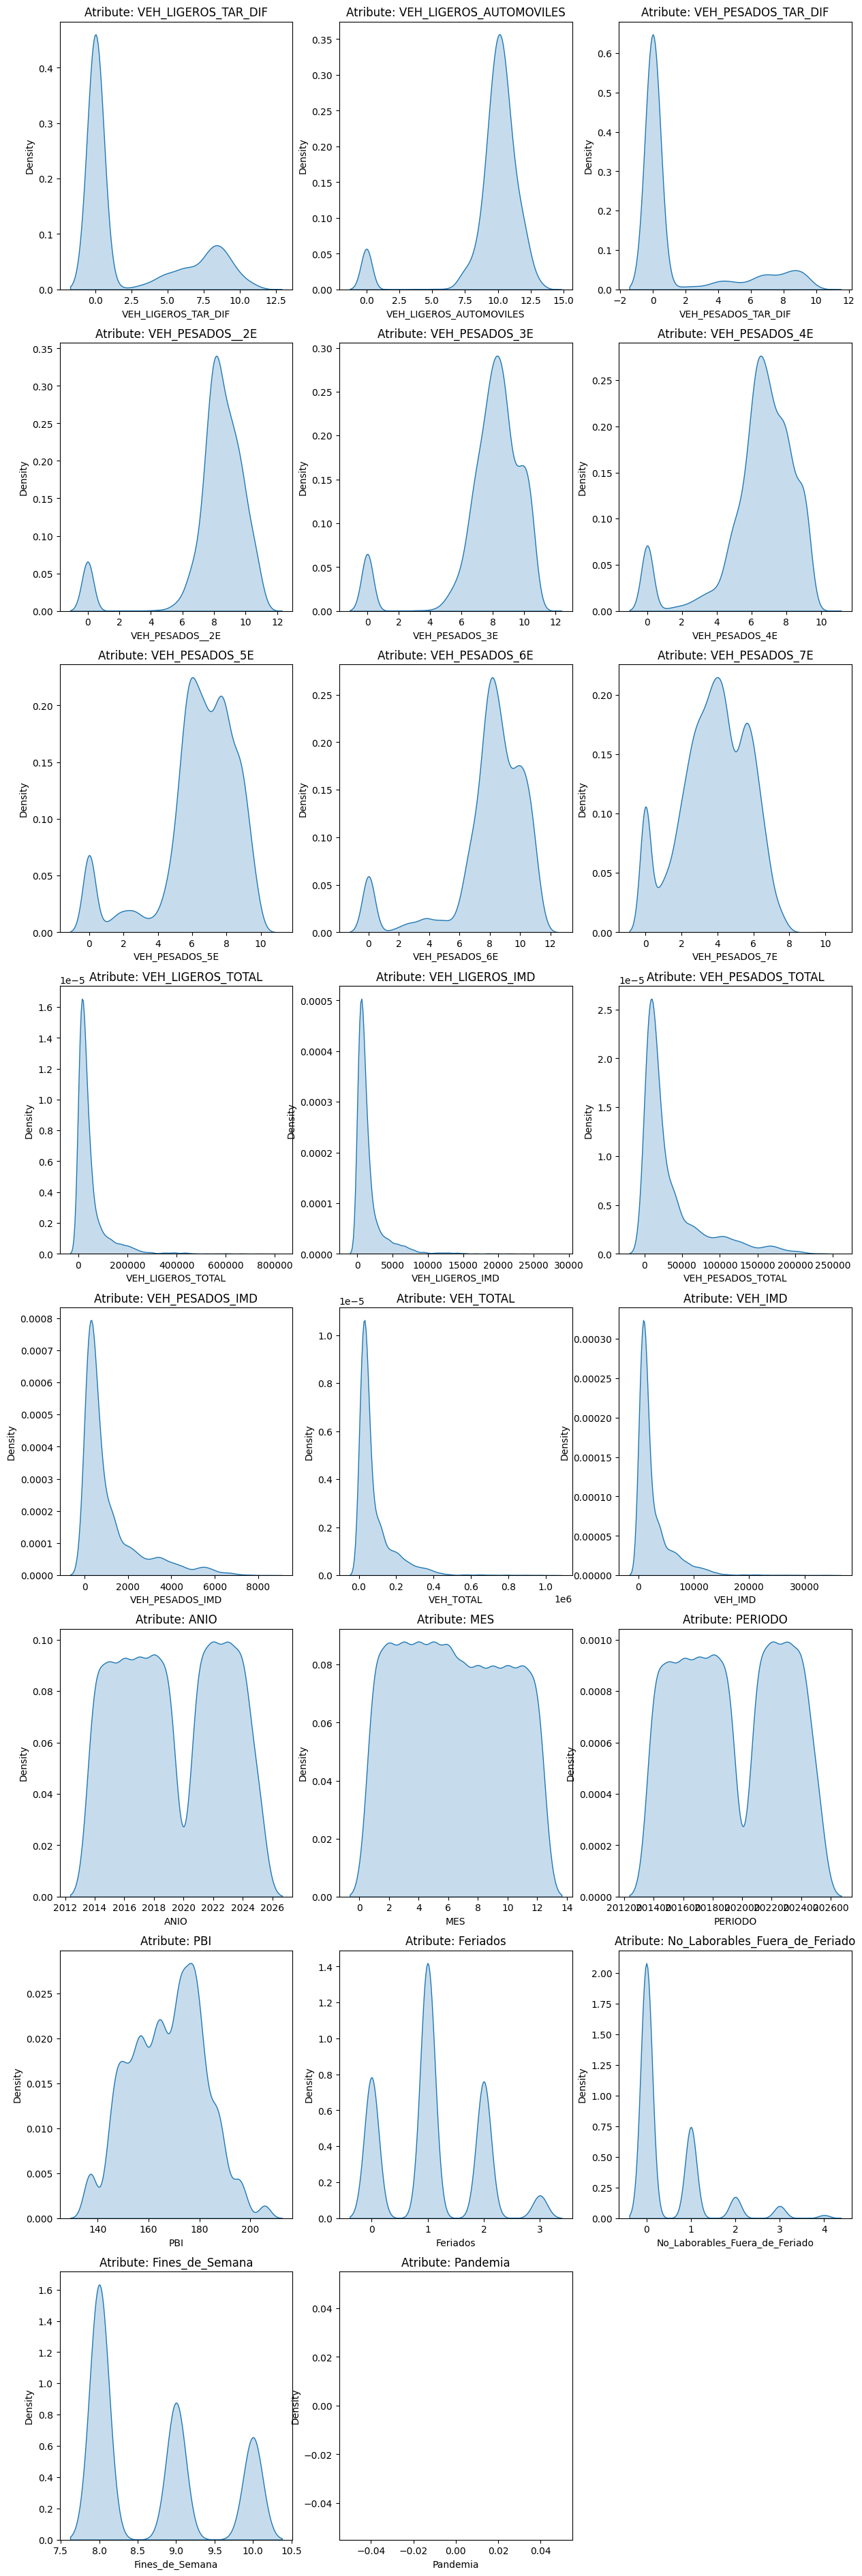

In [25]:
#Graficamos para verificar el cambio

n_cols = 3

n_vars = len(df_prep_num_log.columns)
n_rows = math.ceil( n_vars / n_cols)

plt.figure(figsize=(15, n_rows*6))

for i, atribute in enumerate(df_prep_num_log.columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.kdeplot(df_prep_num_log[atribute], fill=True)
    plt.title(f'Atribute: {atribute}')

In [26]:
# Identificamos outliers numéricos

# Podemos usar z-score (Cuando tenemos gran cantidad de datos y una distribución normal) o iqr (Cuando la cantida de datos es pqueñay tiene una tendencia hacia un lado.)
Q1 = df_prep_num_log.quantile(0.25)
Q3 = df_prep_num_log.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

df_prep_filtered_num = df_prep_num_log[(df_prep_num_log > lower_bound) & (df_prep_num_log < upper_bound)]

df_prep_filtered_num.count()


VEH_LIGEROS_TAR_DIF               9833
VEH_LIGEROS_AUTOMOVILES           9071
VEH_PESADOS_TAR_DIF                  0
VEH_PESADOS__2E                   9203
VEH_PESADOS_3E                    9213
VEH_PESADOS_4E                    9123
VEH_PESADOS_5E                    9014
VEH_PESADOS_6E                    8935
VEH_PESADOS_7E                    9823
VEH_LIGEROS_TOTAL                 8761
VEH_LIGEROS_IMD                   8746
VEH_PESADOS_TOTAL                 8736
VEH_PESADOS_IMD                   8733
VEH_TOTAL                         8936
VEH_IMD                           8953
ANIO                              9833
MES                               9833
PERIODO                           9833
PBI                               9833
Feriados                          9833
No_Laborables_Fuera_de_Feriado    9443
Fines_de_Semana                   9833
Pandemia                             0
dtype: int64

In [27]:
# Imputamos Nulos.
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

rf_optimizado = RandomForestRegressor(
    n_jobs=-1,        
    n_estimators=10,  
    max_depth=10,     
    random_state=42  
)

imputer_num = IterativeImputer(estimator=rf_optimizado, max_iter=5, verbose=2)

df_num_imputed = imputer_num.fit_transform(df_prep_filtered_num)

df_num_imputed

[IterativeImputer] Completing matrix with shape (9833, 21)
[IterativeImputer] Ending imputation round 1/5, elapsed time 3.49
[IterativeImputer] Change: 318973.4425564799, scaled tolerance: 219.013 
[IterativeImputer] Ending imputation round 2/5, elapsed time 7.12
[IterativeImputer] Change: 9674.69614440299, scaled tolerance: 219.013 
[IterativeImputer] Ending imputation round 3/5, elapsed time 10.21
[IterativeImputer] Change: 14763.885282230833, scaled tolerance: 219.013 
[IterativeImputer] Ending imputation round 4/5, elapsed time 13.60
[IterativeImputer] Change: 10522.138747652472, scaled tolerance: 219.013 
[IterativeImputer] Ending imputation round 5/5, elapsed time 17.04
[IterativeImputer] Change: 22075.878770566942, scaled tolerance: 219.013 


c:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\impute\_iterative.py:785: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


array([[ 7.64969262,  8.99603267,  7.85825418, ...,  1.        ,
         1.        ,  8.        ],
       [ 0.        , 10.11232932,  8.78001889, ...,  1.        ,
         1.        ,  8.        ],
       [10.42359001, 11.31618039,  9.79712654, ...,  1.        ,
         1.        ,  8.        ],
       ...,
       [ 0.        , 10.34428763,  8.07402622, ...,  2.        ,
         1.        ,  9.        ],
       [ 0.        ,  7.28436277,  5.59474412, ...,  2.        ,
         1.        ,  9.        ],
       [ 0.        ,  9.44525438,  8.30399997, ...,  2.        ,
         1.        ,  9.        ]])

In [28]:
df_num_imputed = pd.DataFrame(df_num_imputed, columns=df_prep_filtered_num.drop(columns=['Pandemia', 'VEH_PESADOS_TAR_DIF']).columns)

df_num_imputed.head()

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO,PBI,Feriados,No_Laborables_Fuera_de_Feriado,Fines_de_Semana
0,7.649693,8.996033,7.858254,7.772753,6.580639,5.755742,8.164226,2.197225,10169.000000,328.000000,9515.0,306.9,19684.0,635.0,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0
1,0.000000,10.112329,8.780019,8.438799,7.411556,8.015988,9.072457,5.365976,24644.000000,795.000000,24730.0,797.7,49374.0,1592.7,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0
2,10.423590,11.316180,9.797127,8.576970,7.048386,7.460490,8.583543,2.564949,88525.891616,2872.689154,37326.0,1204.1,153108.0,4939.0,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0
3,2.397895,10.756732,9.739909,9.830164,8.403801,8.025843,9.873080,4.912655,46954.000000,1514.600000,62622.0,2020.1,109576.0,3534.7,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0
4,0.000000,10.078784,8.457443,8.279443,6.104793,6.646391,8.280458,4.564348,23831.000000,768.700000,13906.0,448.6,37737.0,1217.3,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0


In [29]:
df_num_imputed.columns

Index(['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS__2E',
       'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E',
       'VEH_PESADOS_7E', 'VEH_LIGEROS_TOTAL', 'VEH_LIGEROS_IMD',
       'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 'VEH_TOTAL', 'VEH_IMD', 'ANIO',
       'MES', 'PERIODO', 'PBI', 'Feriados', 'No_Laborables_Fuera_de_Feriado',
       'Fines_de_Semana'],
      dtype='object')

<AxesSubplot: >

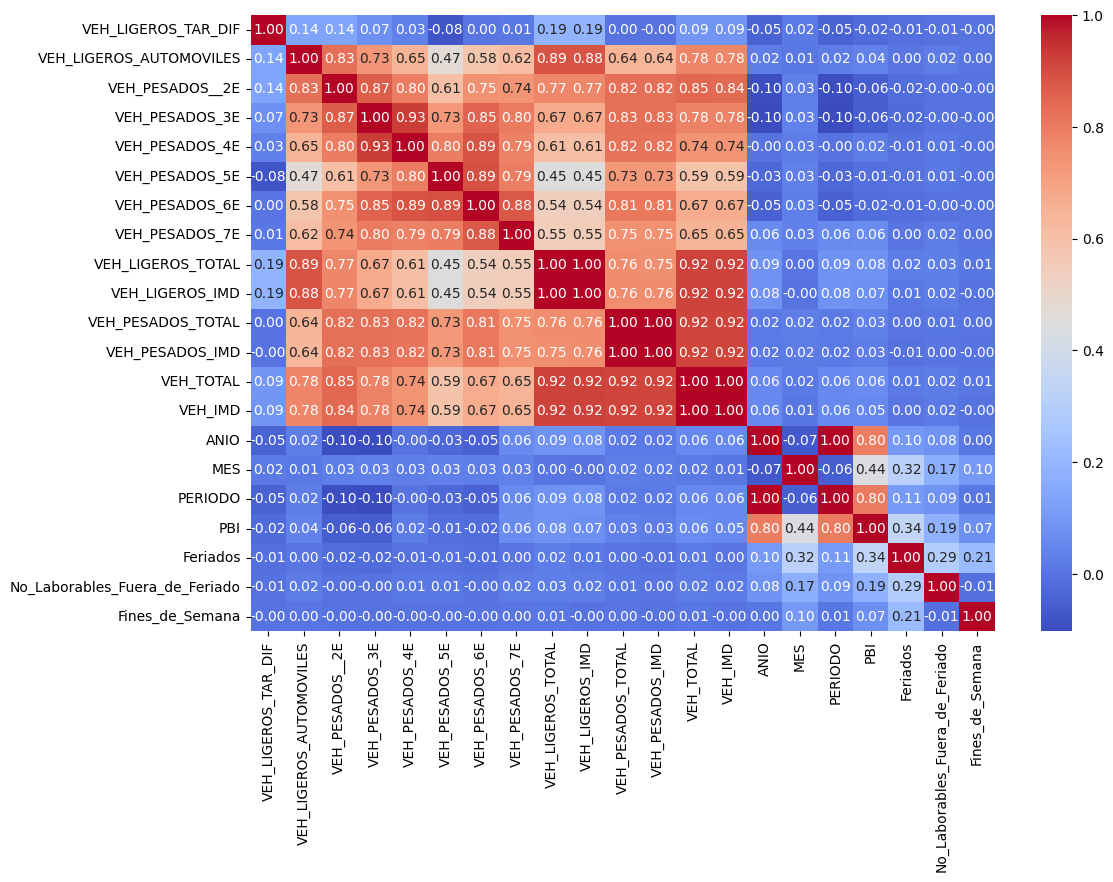

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df_num_imputed.corr()
mask = plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True
)


In [35]:
df_num_imputed.head()

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO,PBI,Feriados,No_Laborables_Fuera_de_Feriado,Fines_de_Semana
0,7.649693,8.996033,7.858254,7.772753,6.580639,5.755742,8.164226,2.197225,10169.000000,328.000000,9515.0,306.9,19684.0,635.0,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0
1,0.000000,10.112329,8.780019,8.438799,7.411556,8.015988,9.072457,5.365976,24644.000000,795.000000,24730.0,797.7,49374.0,1592.7,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0
2,10.423590,11.316180,9.797127,8.576970,7.048386,7.460490,8.583543,2.564949,88525.891616,2872.689154,37326.0,1204.1,153108.0,4939.0,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0
3,2.397895,10.756732,9.739909,9.830164,8.403801,8.025843,9.873080,4.912655,46954.000000,1514.600000,62622.0,2020.1,109576.0,3534.7,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0
4,0.000000,10.078784,8.457443,8.279443,6.104793,6.646391,8.280458,4.564348,23831.000000,768.700000,13906.0,448.6,37737.0,1217.3,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0


In [36]:
# Regresamos a su valor original las columnas transformadas a log1p

df_prep_num_desnorm = df_num_imputed.copy()

for col_2 in columnas_a_normalizar:
    df_prep_num_desnorm[col] = df_num_imputed[col].apply(np.expm1)

In [37]:
df_prep_num_desnorm.head()

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO,PBI,Feriados,No_Laborables_Fuera_de_Feriado,Fines_de_Semana
0,7.649693,8.996033,7.858254,7.772753,6.580639,5.755742,8.164226,8.0,10169.000000,328.000000,9515.0,306.9,19684.0,635.0,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0
1,0.000000,10.112329,8.780019,8.438799,7.411556,8.015988,9.072457,213.0,24644.000000,795.000000,24730.0,797.7,49374.0,1592.7,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0
2,10.423590,11.316180,9.797127,8.576970,7.048386,7.460490,8.583543,12.0,88525.891616,2872.689154,37326.0,1204.1,153108.0,4939.0,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0
3,2.397895,10.756732,9.739909,9.830164,8.403801,8.025843,9.873080,135.0,46954.000000,1514.600000,62622.0,2020.1,109576.0,3534.7,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0
4,0.000000,10.078784,8.457443,8.279443,6.104793,6.646391,8.280458,95.0,23831.000000,768.700000,13906.0,448.6,37737.0,1217.3,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0


In [39]:
df_prep_cat.head() 

,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,llave
0,Concesionado,22PE5NACS1,San Martín,20141
1,Concesionado,04PE1SCAM1,Arequipa,20141
2,Concesionado,21PE3SCRO1,Puno,20141
3,Concesionado,12PE3NCRA1,Junín,20141
4,Concesionado,08PE3SCSC1,Cusco,20141


In [40]:
# juntamos las categorías
df_total_imputed = pd.concat([df_prep_num_desnorm, df_prep_cat], axis=1)

In [41]:
df_total_imputed.head()

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO,PBI,Feriados,No_Laborables_Fuera_de_Feriado,Fines_de_Semana,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,llave
0,7.649693,8.996033,7.858254,7.772753,6.580639,5.755742,8.164226,8.0,10169.000000,328.000000,9515.0,306.9,19684.0,635.0,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0,Concesionado,22PE5NACS1,San Martín,20141
1,0.000000,10.112329,8.780019,8.438799,7.411556,8.015988,9.072457,213.0,24644.000000,795.000000,24730.0,797.7,49374.0,1592.7,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0,Concesionado,04PE1SCAM1,Arequipa,20141
2,10.423590,11.316180,9.797127,8.576970,7.048386,7.460490,8.583543,12.0,88525.891616,2872.689154,37326.0,1204.1,153108.0,4939.0,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0,Concesionado,21PE3SCRO1,Puno,20141
3,2.397895,10.756732,9.739909,9.830164,8.403801,8.025843,9.873080,135.0,46954.000000,1514.600000,62622.0,2020.1,109576.0,3534.7,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0,Concesionado,12PE3NCRA1,Junín,20141
4,0.000000,10.078784,8.457443,8.279443,6.104793,6.646391,8.280458,95.0,23831.000000,768.700000,13906.0,448.6,37737.0,1217.3,2014.0,1.0,201401.0,136.331425,1.0,1.0,8.0,Concesionado,08PE3SCSC1,Cusco,20141


In [42]:
df_total_imputed.columns

Index(['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS__2E',
       'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E',
       'VEH_PESADOS_7E', 'VEH_LIGEROS_TOTAL', 'VEH_LIGEROS_IMD',
       'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 'VEH_TOTAL', 'VEH_IMD', 'ANIO',
       'MES', 'PERIODO', 'PBI', 'Feriados', 'No_Laborables_Fuera_de_Feriado',
       'Fines_de_Semana', 'ADMINIST', 'CODIGO_PEAJE', 'DEPARTAMENTO', 'llave'],
      dtype='object')

In [43]:
df_total_imputed_f = df_total_imputed[~df_total_imputed['PERIODO'].isnull()]

In [44]:
df_total_imputed_f.to_csv('../Data/Processed/Flujo_Vehicular_procesado.csv', encoding='latin-1', index=False)

In [ ]:
# Buscar otras variables exogenas que nos puedan ayudar con la precisión para poder entrenar el modelo, clima, feriados, 
# fines de semana, feriados, huelgas y paros, cambios de gobierno --> Jose 
# Que otras varibales son consideradas, tarifas, precios, situacion económica del pais (PBI) --> Mario, Jesus y Efflyn